# **Análisis de Componentes Principales (PCA) - Breast Cancer Dataset**

Camila Johana Gonzalez Acosta
Matricula: 599303

Este notebook presenta el procedimiento completo de Análisis de Componentes Principales (PCA) aplicado al dataset Breast Cancer Wisconsin Diagnostic.


## Importación de librerías

Se importan las librerías necesarias para la manipulación de datos, visualización y cálculo matemático requerido para PCA.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler


## Carga del dataset

Se carga el dataset Breast Cancer Wisconsin desde sklearn.

Este dataset pertenece al dominio médico y contiene mediciones extraídas de imágenes de células mamarias.

Las variables predictoras representan características celulares, y la variable target representa el diagnóstico:

- 0 = maligno
- 1 = benigno


In [7]:
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)

df["target"] = data.target

df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Se observa que el dataset contiene múltiples variables predictoras numéricas y una variable objetivo que representa la clasificación.


## Dimensiones del dataset

Se verifica el número de observaciones y variables del dataset.


In [8]:
df.shape


(569, 31)

Se observa que el dataset contiene 569 observaciones y 31 variables en total, de las cuales 30 son variables predictoras y 1 es la variable objetivo.


## Tipos de datos

Se verifica el tipo de cada variable del dataset.


In [10]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

Se observa que todas las variables predictoras son de tipo float64, lo cual es adecuado ya que representan mediciones continuas.

La variable target es de tipo int64, ya que representa una etiqueta de clasificación discreta.


## Verificación de valores faltantes

Se verifica si el dataset contiene valores faltantes.


In [11]:
df.isnull().sum()


,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


Se observa que no existen valores faltantes en el dataset, por lo que no es necesario realizar limpieza adicional.


## Separación de variables predictoras

Se separan las variables predictoras de la variable objetivo.

PCA se aplica únicamente a las variables predictoras.


In [12]:
X = df.drop("target", axis=1)

X.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Análisis estadístico

Se calculan estadísticas descriptivas para analizar la escala de las variables.


In [13]:
X.describe()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


Se observa que las variables presentan escalas significativamente diferentes.

Por ejemplo:

- Las variables relacionadas con el área presentan valores elevados.
- Variables como smoothness presentan valores pequeños.

Esto confirma la necesidad de estandarizar los datos antes de aplicar PCA, ya que el método es sensible a la escala.


## Estandarización de los datos

Se estandarizan las variables para que cada una tenga media cero y desviación estándar igual a uno.

Este paso es necesario para evitar que variables con mayor escala dominen el análisis.


In [14]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


Se verifica que después de la estandarización, cada variable tiene media cercana a cero y desviación estándar cercana a uno.


In [15]:
np.mean(X_scaled, axis=0)


,0
mean radius,-3.162867e-15
mean texture,-6.530609e-15
mean perimeter,-7.078891e-16
mean area,-8.799835e-16
mean smoothness,6.132177e-15
mean compactness,-1.120369e-15
mean concavity,-4.421380e-16
mean concave points,9.732500e-16
mean symmetry,-1.971670e-15
mean fractal dimension,-1.453631e-15


In [16]:
np.std(X_scaled, axis=0)


,0
mean radius,1.0
mean texture,1.0
mean perimeter,1.0
mean area,1.0
mean smoothness,1.0
mean compactness,1.0
mean concavity,1.0
mean concave points,1.0
mean symmetry,1.0
mean fractal dimension,1.0


Se observa que las medias son cercanas a cero y las desviaciones estándar cercanas a uno, lo que confirma que la estandarización se realizó correctamente.


## Visualización gráfica de la matriz de covarianza

Se visualiza la matriz de covarianza utilizando un mapa de calor (heatmap).

Esta representación permite identificar visualmente la relación entre las variables.

Los colores más claros representan mayor covarianza positiva, mientras que los colores más oscuros representan covarianza negativa o menor relación.


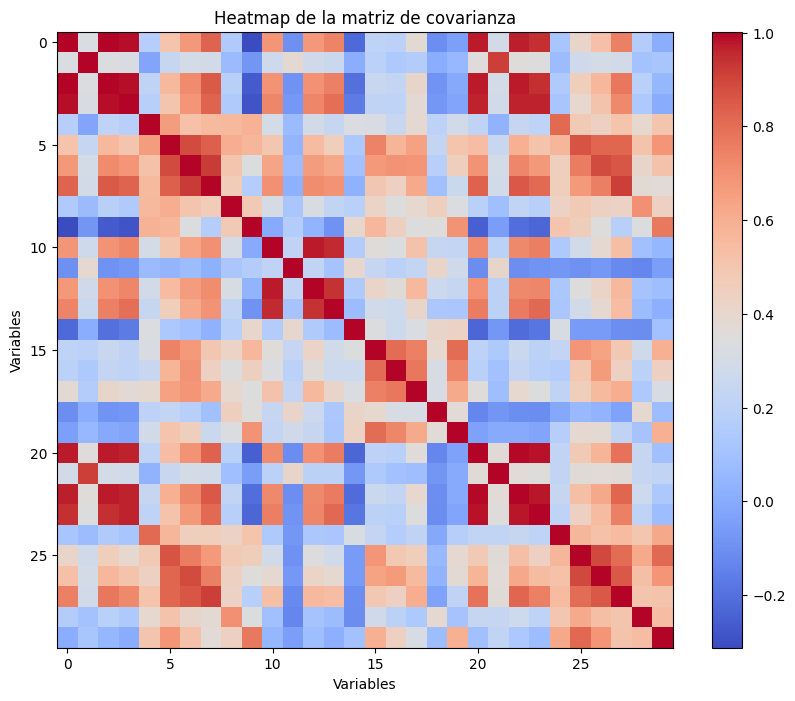

In [20]:
plt.figure(figsize=(10,8))

plt.imshow(cov_matrix, cmap='coolwarm')

plt.colorbar()

plt.title("Heatmap de la matriz de covarianza")

plt.xlabel("Variables")

plt.ylabel("Variables")

plt.show()


Se observa que existen múltiples regiones con alta covarianza positiva, lo que indica que varias variables están altamente correlacionadas.

Esto sugiere que existe redundancia en la información del dataset, lo cual confirma que PCA es una técnica adecuada para reducir la dimensionalidad.

También se observa que la matriz es simétrica, lo cual es una propiedad característica de las matrices de covarianza.


## Eigenvalues y Eigenvectors

Se calculan los eigenvalues y eigenvectors de la matriz de covarianza.

Los eigenvalues representan la cantidad de varianza explicada por cada componente principal.

Se ordenan los eigenvalues de mayor a menor.



In [23]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

eigenvalues


array([1.33049908e+01, 5.70137460e+00, 2.82291016e+00, 1.98412752e+00,
       1.65163324e+00, 1.20948224e+00, 6.76408882e-01, 4.77456255e-01,
       4.17628782e-01, 3.51310875e-01, 2.94433153e-01, 2.61621161e-01,
       2.41782421e-01, 1.57286149e-01, 9.43006956e-02, 8.00034045e-02,
       5.95036135e-02, 5.27114222e-02, 4.95647002e-02, 1.33279057e-04,
       7.50121413e-04, 1.59213600e-03, 6.91261258e-03, 8.19203712e-03,
       1.55085271e-02, 1.80867940e-02, 2.43836914e-02, 2.74877113e-02,
       3.12142606e-02, 3.00256631e-02])

In [24]:
idx = eigenvalues.argsort()[::-1]

eigenvalues = eigenvalues[idx]

eigenvectors = eigenvectors[:, idx]


## Varianza explicada

Se calcula el porcentaje de varianza explicada por cada componente principal.


In [25]:
explained_variance = eigenvalues / np.sum(eigenvalues)

explained_variance


array([4.42720256e-01, 1.89711820e-01, 9.39316326e-02, 6.60213492e-02,
       5.49576849e-02, 4.02452204e-02, 2.25073371e-02, 1.58872380e-02,
       1.38964937e-02, 1.16897819e-02, 9.79718988e-03, 8.70537901e-03,
       8.04524987e-03, 5.23365745e-03, 3.13783217e-03, 2.66209337e-03,
       1.97996793e-03, 1.75395945e-03, 1.64925306e-03, 1.03864675e-03,
       9.99096464e-04, 9.14646751e-04, 8.11361259e-04, 6.01833567e-04,
       5.16042379e-04, 2.72587995e-04, 2.30015463e-04, 5.29779290e-05,
       2.49601032e-05, 4.43482743e-06])

Se visualiza la varianza explicada por cada componente.


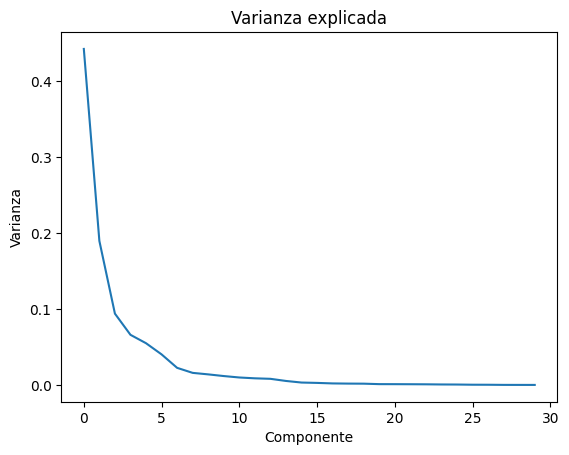

In [26]:
plt.figure()

plt.plot(explained_variance)

plt.title("Varianza explicada")

plt.xlabel("Componente")

plt.ylabel("Varianza")

plt.show()


Se observa que los primeros componentes explican la mayor parte de la varianza del dataset.


## Matriz de transformación y obtención de los componentes principales (2D)

Se construye la matriz de transformación utilizando los eigenvectors correspondientes a los dos mayores eigenvalues.

Esta matriz permite proyectar los datos originales estandarizados en un nuevo espacio de menor dimensión.

El resultado son los componentes principales, que representan combinaciones lineales de las variables originales.


In [30]:
W2 = eigenvectors[:, :2]

X_pca_2d = np.dot(X_scaled.values, W2)

X_pca_2d = pd.DataFrame(X_pca_2d, columns=["PC1", "PC2"])

X_pca_2d.head()


,PC1,PC2
0,9.192837,1.948583
1,2.387802,-3.768172
2,5.733896,-1.075174
3,7.122953,10.275589
4,3.935302,-1.948072


Se observa que los datos han sido transformados correctamente al nuevo espacio definido por los dos componentes principales.

Cada observación ahora está representada por dos valores en lugar de las 30 variables originales.

Esto representa una reducción significativa en la dimensionalidad del dataset.


## Visualización de los dos primeros componentes principales

Se visualizan los datos proyectados en el espacio definido por los dos primeros componentes principales.

Cada punto representa una observación y el color indica su clasificación.


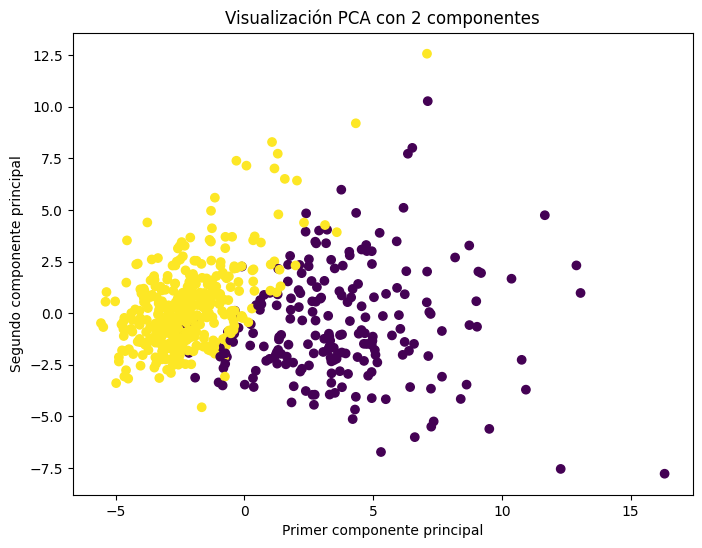

In [31]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca_2d["PC1"],
    X_pca_2d["PC2"],
    c=df["target"]
)

plt.xlabel("Primer componente principal")

plt.ylabel("Segundo componente principal")

plt.title("Visualización PCA con 2 componentes")

plt.show()


Se observa una clara separación entre las dos clases en el espacio de los componentes principales.

Esto indica que PCA logra preservar la estructura del dataset y facilita la diferenciación entre observaciones malignas y benignas.

Esto confirma que PCA es efectivo para reducir la dimensionalidad sin perder información importante.


## Obtención de los tres primeros componentes principales

Se construye la matriz de transformación utilizando los tres primeros eigenvectors.

Esto permite representar los datos en un espacio tridimensional.


In [33]:
W3 = eigenvectors[:, :3]

X_pca_3d = np.dot(X_scaled.values, W3)

X_pca_3d = pd.DataFrame(X_pca_3d, columns=["PC1", "PC2", "PC3"])

X_pca_3d.head()


,PC1,PC2,PC3
0,9.192837,1.948583,-1.123166
1,2.387802,-3.768172,-0.529293
2,5.733896,-1.075174,-0.551748
3,7.122953,10.275589,-3.232790
4,3.935302,-1.948072,1.389767


Se observa que los datos han sido transformados correctamente en un espacio tridimensional.

Esto permite preservar aún más información del dataset original en comparación con la representación en dos dimensiones.


## Varianza explicada acumulada

Se calcula la varianza explicada acumulada para determinar cuántos componentes principales son necesarios para preservar la mayor parte de la información.


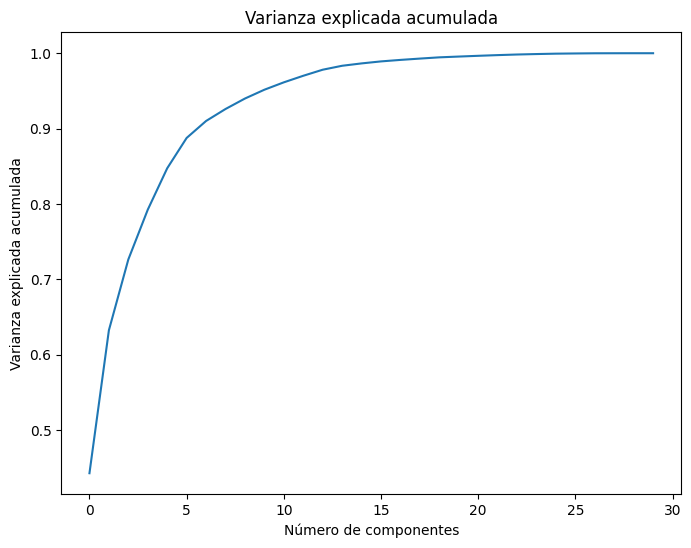

In [34]:
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)

cumulative_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(8,6))

plt.plot(cumulative_variance)

plt.xlabel("Número de componentes")

plt.ylabel("Varianza explicada acumulada")

plt.title("Varianza explicada acumulada")

plt.show()


Se observa que la varianza explicada acumulada aumenta rápidamente en los primeros componentes principales y luego se estabiliza.

Esto indica que la mayor parte de la información del dataset se concentra en un número reducido de componentes.

Por ejemplo, con aproximadamente 5 componentes principales se puede explicar alrededor del 90% de la varianza total, lo que representa una reducción significativa desde las 30 variables originales.

Esto confirma que PCA es efectivo para reducir la dimensionalidad del dataset sin perder información relevante.


## Conclusiones

Se aplicó Principal Component Analysis (PCA) al dataset Breast Cancer Wisconsin con el objetivo de reducir su dimensionalidad y analizar su estructura.

Se observó que las variables presentan correlaciones importantes, lo que permitió que los primeros componentes principales capturaran la mayor parte de la varianza del dataset. La visualización en dos dimensiones mostró una separación clara entre las clases, lo que indica que la información relevante se conserva después de la reducción.

La aplicación de PCA permitió simplificar el dataset sin perder información significativa, facilitando su uso en modelos de clasificación. Esto demuestra que PCA es una técnica efectiva para el análisis y preprocesamiento de datos en aplicaciones de machine learning y redes neuronales.

**Github Repository:** https://github.com/camilagzzaa/02-Principal-Component-Analysis.git


## References

Dua, D., & Graff, C. (2019). *UCI Machine Learning Repository*. University of California, Irvine, School of Information and Computer Sciences. https://archive.ics.uci.edu

Scikit-learn developers. (2024). *Breast cancer dataset*. Scikit-learn. https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html

